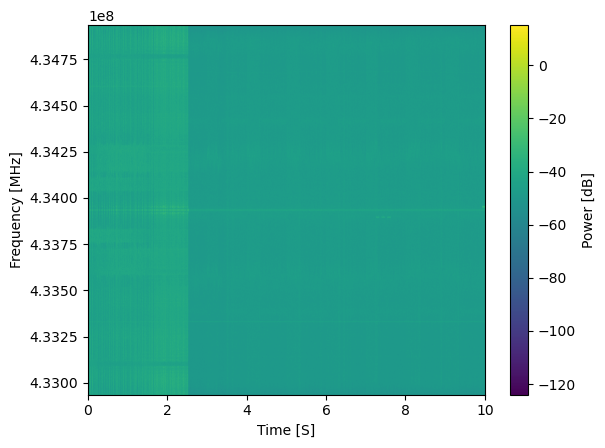

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import iio
import adi 

center_freq = 433.9353e6 #Hz
sample_rate= 2e6 #Msps
capture_duration_sec = 1 #capturing data for 1 second
capture_duration_total = 10 # total capture time 10 seconds
fft_size = 8192

num_samps=int(capture_duration_sec*sample_rate) #If duration of DTS(T) = N/fs then T*Fs = N

sdr = adi.Pluto("ip:192.168.2.1") #class in adi.ad936x device 
sdr.sample_rate= int(sample_rate) # sample rate = 2MHz way more than the 3KHz bandwidth wireless signal.
sdr.rx_lo = int(center_freq) # carrier freq of Rx


sdr.gain_control_mode_chan0 = "manual" # can set gain of Rx and turns off AGC which changes the gain over time?
sdr.rx_hardwaregain_chan0 = 60.0 #dB Placeholder value change if needed?


sdr.rx_rf_bandwidth=int(sample_rate)
sdr.rx_buffer_size = num_samps # number of samples returned 

samples=sdr.rx() #receive samples off Pluto 

# repeatedly capture samples so that the OS's network driver doesn't time out
for i in range(1,capture_duration_total):
    samples = np.concatenate((samples, sdr.rx()))

def spectrogram_plot(y,Fs,N,Fc):
    
    plt.specgram(y,NFFT=N,Fs=Fs,noverlap=N//2,Fc=Fc,scale='dB') #matplotlib syntax for spectrogram
    plt.ylabel("Frequency [MHz]")
    plt.xlabel("Time [S]")
    plt.xlim(0, capture_duration_total)
    plt.colorbar(label="Power [dB]") #labels colorbar 
    plt.show()


spectrogram_plot(samples,sdr.sample_rate,8192,center_freq) #FFT size = 8192 because frequency res = sampling freq/FFT size ---> 2*10^6/8192= 244 Hz wide!